# NB1 — Demand Forecasting & Delivery-Risk Scores

**Scope.** Produces two consumer parquets for downstream notebooks:
- `outputs/nb1_weekly_order_volume.parquet` — weekly order count per seller (consumed by NB2's lead-indicator section).
- `outputs/nb1_seller_demand_scores.parquet` — per-seller forecast uplift, average delivery delay, delay-risk flag (feeds the convergence layer).

**Rubric surface in this notebook.** RDDs (`textFile → filter → map → reduceByKey → typed DF`) · DataFrames · SparkSQL (≥3 queries on temp views) · ML `Pipeline(Imputer → VectorAssembler)` · MLlib `GBTRegressor` + `RandomForestRegressor` under `CrossValidator(folds=3)` with `RegressionEvaluator(rmse)` · Window functions (lag / rolling) · `approxQuantile` / `approx_count_distinct`.

**Narrative structure.** This notebook follows the **CRISP-DM** methodology — six sections from *Business Understanding* to *Deployment*. Every code cell calls into `src/olist/pipeline/demand.py`; every chart/table goes through `src/olist/viz.py`.

## 0. Boot — `SparkSession` + `JAVA_HOME`

Local Homebrew OpenJDK 11, `spark.driver.memory=6g`, `shuffle_partitions=64`, time zone `America/Sao_Paulo` — all configured in `src/olist/spark_session.py`.

In [1]:
import os, sys, inspect
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@11/libexec/openjdk.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from olist.spark_session import get_spark
from pyspark.sql import functions as F

spark = get_spark("nb1-demand-forecasting")
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 22:23:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.8


## 1. Business Understanding

**Why demand forecasting matters to Olist.** A seller's health is the combination of *where the demand is going* and *whether they can deliver it on time*. This notebook builds the **demand component** of the Seller Risk Index:

- **Forecast-uplift signal.** Predicted next-4-week order volume vs. trailing-4-week actuals — is this seller growing, stable, or shrinking?
- **Delay signal.** Average delivery delay (days beyond the estimated date) and a `delay_risk_flag` (1 iff `avg_delay_days > 3`).
- **Structural signal.** Weekly-volume trajectories per seller drive both the forecast and the lead-indicator work in NB2.

**Stakeholder question.** *"Which sellers are trending down in volume, shipping late, or both — so account management can intervene before the pipeline dries up?"* — the per-seller demand parquet written in §6 answers this row-by-row.

## 2. Data Understanding

Seven typed CSVs combine into the hot DataFrame: `orders ⋈ order_items ⋈ broadcast(sellers) ⋈ broadcast(products)`, filtered to *delivered* orders. Every load uses a pre-declared `StructType` from `src/olist/schemas.py` — no `inferSchema=True`, so no extra full-file pass.

### 2.1 RDD warm-up — `textFile → filter → map → reduceByKey → typed DF`

The rubric explicitly asks to demonstrate the RDD API even on a dataset this size. We read `olist_orders_dataset.csv` as raw text, strip the header, map each row to `(purchase_date, 1)`, filter bad rows, `reduceByKey`, and rebuild a typed DataFrame. The chain itself is printed below — no duplicated logic.

In [2]:
from olist.pipeline.demand import rdd_daily_order_count

print(inspect.getsource(rdd_daily_order_count))


def rdd_daily_order_count(spark: SparkSession) -> DataFrame:
    """Demonstrate the required RDD primitive: read the raw orders CSV as text,
    split / filter / reduceByKey into a (date → order-count) pair, and rebuild
    a typed DataFrame with an explicit schema.

    The returned DataFrame is only used for a sanity check against the typed
    loader — downstream work reads the typed DataFrame via `loaders.load_orders`.
    """
    data_dir = Path(__file__).resolve().parents[3] / "data"
    orders_csv = str(data_dir / "olist_orders_dataset.csv")
    raw = spark.sparkContext.textFile(orders_csv)
    header = raw.first()

    def _parse(line: str):
        try:
            parts = line.split(",")
            ts = parts[3]  # order_purchase_timestamp
            if not ts:
                return None
            return (datetime.strptime(ts[:10], "%Y-%m-%d").date(), 1)
        except Exception:
            return None

    daily_pairs = (
        raw.filter(lambda row: row != header)
 

In [3]:
daily_orders_rdd_df = rdd_daily_order_count(spark)
print(f"RDD-derived daily rows: {daily_orders_rdd_df.count():,}")
daily_orders_rdd_df.orderBy("purchase_date").limit(5).show()


RDD-derived daily rows: 634


+-------------+-----------+
|purchase_date|order_count|
+-------------+-----------+
|   2016-09-04|          1|
|   2016-09-05|          1|
|   2016-09-13|          1|
|   2016-09-15|          1|
|   2016-10-02|          1|
+-------------+-----------+



### 2.2 Typed loads + row audit

In [4]:
from olist.pipeline.demand import load_core_tables

tables = load_core_tables(spark)
for name, df in tables.items():
    print(f"{name:>24}: {df.count():>8,}")


                  orders:   99,441
             order_items:  112,650


               customers:   99,441
                 sellers:    3,095
                products:   32,951


           order_reviews:  104,162
    category_translation:       71


### 2.3 Filter to delivered orders

In [5]:
from olist.pipeline.demand import filter_delivered

orders = tables["orders"]
orders_delivered = filter_delivered(orders)
dropped = orders.count() - orders_delivered.count()
print(f"orders dropped (not-yet-delivered / cancelled): {dropped:,}")
print(f"orders retained: {orders_delivered.count():,}")


orders dropped (not-yet-delivered / cancelled): 2,965


orders retained: 96,476


### 2.4 EDA primitives — `approxQuantile` + `approx_count_distinct`

Both are big-data-safe: quantiles are computed on a sketch (1% relative error here), `approx_count_distinct` is a HyperLogLog sketch — neither requires a full shuffle.

In [6]:
from olist.pipeline.demand import build_order_lines, eda_stats
from olist import viz

order_lines = build_order_lines(spark)
print(f"order_lines rows: {order_lines.count():,}")

stats = eda_stats(order_lines)
print("price quantiles (p25/p50/p75/p95):", stats["price_quantiles"])
print("delay quantiles (p25/p50/p75/p95):", stats["delay_quantiles"])
stats["approx_counts"].show()

# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — 2-row styled table
viz.eda_quantile_table(stats)


[cache] skip demand.order_lines (176d296f…)


order_lines rows: 110,196


price quantiles (p25/p50/p75/p95): [39.9, 72.9, 129.99, 310.0]
delay quantiles (p25/p50/p75/p95): [-17.0, -13.0, -8.0, 1.0]


26/04/24 22:24:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------+---------------+
|approx_sellers|approx_products|
+--------------+---------------+
|          2965|          32138|
+--------------+---------------+



metric,p25,p50,p75,p95
price (R$),39.90,72.90,129.99,310.00
delivery delay (days),-17.00,-13.00,-8.00,1.00


### 2.5 SparkSQL — three queries on a temp view

The rubric asks for ≥3 SparkSQL queries on temp views. We print the SQL text inline so both the query and its result are visible. Two of the three results are rendered as consulting-quality visuals in the next subsections.

In [7]:
from olist.pipeline.demand import sparksql_queries

queries = sparksql_queries(order_lines)
for name, (sql, result) in queries.items():
    print(f"\n--- {name} ---")
    print(sql.strip())
    result.show(truncate=False)



--- top_sellers_by_revenue ---
SELECT seller_id,
           seller_state,
           ROUND(SUM(price), 2) AS total_revenue,
           COUNT(*)             AS line_count
    FROM order_lines
    GROUP BY seller_id, seller_state
    ORDER BY total_revenue DESC
    LIMIT 10


+--------------------------------+------------+-------------+----------+
|seller_id                       |seller_state|total_revenue|line_count|
+--------------------------------+------------+-------------+----------+
|4869f7a5dfa277a7dca6462dcf3b52b2|SP          |226987.93    |1148      |
|53243585a1d6dc2643021fd1853d8905|BA          |217940.44    |400       |
|4a3ca9315b744ce9f8e9374361493884|SP          |196882.12    |1949      |
|fa1c13f2614d7b5c4749cbc52fecda94|SP          |190917.14    |579       |
|7c67e1448b00f6e969d365cea6b010ab|SP          |186570.05    |1355      |
|7e93a43ef30c4f03f38b393420bc753a|SP          |165981.49    |322       |
|da8622b14eb17ae2831f4ac5b9dab84a|SP          |159816.87    |1548      |
|7a67c85e85bb2ce8582c35f2203ad736|SP          |139658.69    |1155      |
|1025f0e2d44d7041d6cf58b6550e0bfa|SP          |138208.56    |1420      |
|955fee9216a65b617aa5c0531780ce60|SP          |131836.71    |1472      |
+--------------------------------+------------+----

+--------------------------------+---------+------------------+
|seller_id                       |year_week|weekly_order_count|
+--------------------------------+---------+------------------+
|0015a82c2db000af6aaaf3ae2ecb0532|2017-39  |1                 |
|0015a82c2db000af6aaaf3ae2ecb0532|2017-41  |1                 |
|0015a82c2db000af6aaaf3ae2ecb0532|2017-42  |1                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-05  |1                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-07  |5                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-08  |1                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-09  |7                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-11  |4                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-12  |6                 |
|001cca7ae9ae17fb1caed9dfb1094831|2017-13  |5                 |
+--------------------------------+---------+------------------+


--- late_rate_by_state ---
SELECT seller_state,
           ROUND(AVG(CASE WHEN delivery_delay_days > 0

+------------+---------+--------------+-------+
|seller_state|late_rate|avg_delay_days|n_lines|
+------------+---------+--------------+-------+
|AM          |0.3333   |9.0           |3      |
|MA          |0.1940   |-11.26        |402    |
|RN          |0.0714   |-13.48        |56     |
|SP          |0.0711   |-11.3         |78600  |
|RJ          |0.0691   |-12.51        |4689   |
|CE          |0.0667   |-13.38        |90     |
|MS          |0.0600   |-17.38        |50     |
|DF          |0.0600   |-13.18        |883    |
|ES          |0.0577   |-13.36        |364    |
|PR          |0.0530   |-14.23        |8487   |
|SC          |0.0485   |-14.2         |4000   |
|MG          |0.0479   |-13.47        |8602   |
|BA          |0.0449   |-12.81        |624    |
|MT          |0.0417   |-15.63        |144    |
|PE          |0.0337   |-16.24        |445    |
+------------+---------+--------------+-------+



### 2.6 Top-10 sellers by revenue — styled table

The revenue distribution is heavily skewed: a small fraction of sellers produce the majority of GMV. The styled table below embeds a magnitude bar on `total_revenue` so the long-tail shape is visible at a glance.

In [8]:
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 10 rows
top10_revenue = queries["top_sellers_by_revenue"][1].toPandas()
top10_revenue["seller_id"] = top10_revenue["seller_id"].str.slice(0, 10) + "…"
viz.styled_topn_table(
    top10_revenue,
    bar_cols=["total_revenue"],
    fmt={"total_revenue": "R$ {:,.0f}", "line_count": "{:,d}"},
    title="Top-10 sellers by total revenue",
)


seller_id,seller_state,total_revenue,line_count
4869f7a5df…,SP,"R$ 226,988","1,148"
53243585a1…,BA,"R$ 217,940",400
4a3ca9315b…,SP,"R$ 196,882","1,949"
fa1c13f261…,SP,"R$ 190,917",579
7c67e1448b…,SP,"R$ 186,570","1,355"
7e93a43ef3…,SP,"R$ 165,981",322
da8622b14e…,SP,"R$ 159,817","1,548"
7a67c85e85…,SP,"R$ 139,659","1,155"
1025f0e2d4…,SP,"R$ 138,209","1,420"
955fee9216…,SP,"R$ 131,837","1,472"


### 2.7 Late-delivery rate by state — bar chart

State-level context for the delay signal. The bar is coloured by value (more red = later); 15-state cap comes from the SparkSQL `LIMIT 15` to keep the chart readable.

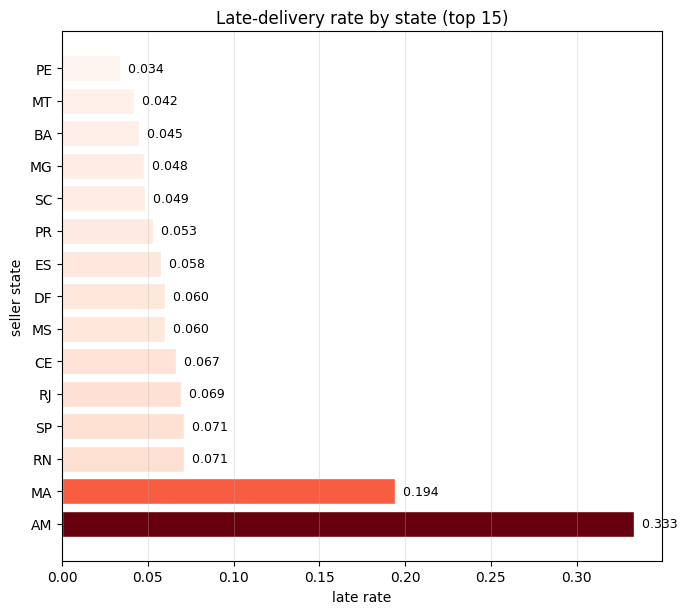

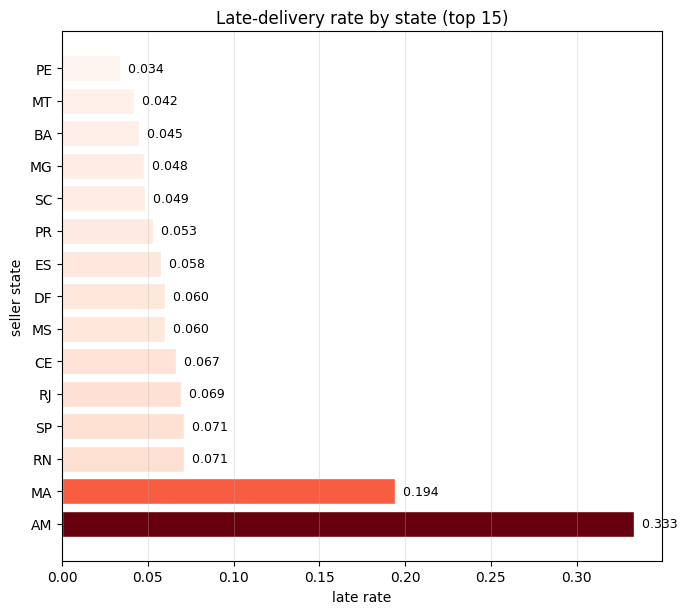

In [9]:
# BIG-DATA-SAFETY-ESCAPE: STATE_AGG_VIZ — ≤15-row per-state aggregate
late_state = queries["late_rate_by_state"][1].toPandas()
# Spark ROUND returns DECIMAL → pandas Decimal; matplotlib needs float
late_state["late_rate"] = late_state["late_rate"].astype(float)
late_state["avg_delay_days"] = late_state["avg_delay_days"].astype(float)
viz.state_bar(
    late_state,
    value_col="late_rate",
    label_col="seller_state",
    title="Late-delivery rate by state (top 15)",
    sort="desc",
)


## 3. Data Preparation

Two transformations feed the modelling step:

1. **Geolocation centroids.** The raw `olist_geolocation_dataset.csv` has many rows per zip; we reduce to centroids once and broadcast (≤10 MB) to every join that needs it. `@step` caches the parquet.
2. **Weekly order volume per seller** via Window functions, plus lag / rolling / calendar features — the "Pipelines & Data Engineering" rubric surface.

### 3.1 Geolocation centroids

In [10]:
from olist.pipeline.demand import build_geo_centroids

geo_centroids = build_geo_centroids(spark)
print(f"geo_centroids rows: {geo_centroids.count():,}")
geo_centroids.limit(3).show()


[cache] run demand.geo_centroids (1.8s, wrote 19015 rows → outputs/geo_centroids.parquet)
geo_centroids rows: 19,015
+---------------------------+-------------------+-------------------+-----+
|geolocation_zip_code_prefix|                lat|                lng|state|
+---------------------------+-------------------+-------------------+-----+
|                       1001|-23.550189776551765|-46.634023555904214|   SP|
|                       1002| -23.54814573176355| -46.63497921074498|   SP|
|                       1003|-23.548993724813155| -46.63573130997587|   SP|
+---------------------------+-------------------+-------------------+-----+



### 3.2 Weekly order volume — parquet consumed by NB2

In [11]:
from olist.pipeline.demand import build_weekly_order_volume

weekly_order_volume = build_weekly_order_volume(spark)
print(f"weekly rows: {weekly_order_volume.count():,}")
weekly_order_volume.orderBy("seller_id", "year_week").limit(5).show()


[cache] run demand.weekly_order_volume (0.6s, wrote 35385 rows → outputs/nb1_weekly_order_volume.parquet)
weekly rows: 35,385
+--------------------+---------+------------------+
|           seller_id|year_week|weekly_order_count|
+--------------------+---------+------------------+
|0015a82c2db000af6...|  2017-39|                 1|
|0015a82c2db000af6...|  2017-41|                 1|
|0015a82c2db000af6...|  2017-42|                 1|
|001cca7ae9ae17fb1...|  2017-05|                 1|
|001cca7ae9ae17fb1...|  2017-07|                 5|
+--------------------+---------+------------------+



### 3.3 Feature engineering — `Imputer → VectorAssembler` + Window features

Two Pipeline stages (`Imputer` median-imputes `lag_1`, `lag_4`, `rolling_4w_mean`; `VectorAssembler` bundles the six model features). Window primitives: `Window.partitionBy(seller_id).orderBy(year_week)` plus a `rowsBetween(-4, -1)` frame for the rolling mean.

In [12]:
from olist.pipeline.demand import build_feature_pipeline, add_weekly_features, FEATURE_COLS

feature_pipeline = build_feature_pipeline()
print("Pipeline stages:")
for stage in feature_pipeline.getStages():
    print(" ", stage)
print("\nFeature columns:", FEATURE_COLS)


Pipeline stages:
  Imputer_a7e599f55394
  VectorAssembler_b3e764b35692

Feature columns: ['week_num', 'lag_1', 'lag_4', 'rolling_4w_mean', 'month', 'is_q4']


In [13]:
weekly_features = add_weekly_features(weekly_order_volume)
print(f"weekly_features rows: {weekly_features.count():,}")
weekly_features.select("seller_id", "year_week", "weekly_order_count", *FEATURE_COLS).limit(5).show()


weekly_features rows: 35,385


+--------------------+---------+------------------+--------+-----+-----+---------------+-----+-----+
|           seller_id|year_week|weekly_order_count|week_num|lag_1|lag_4|rolling_4w_mean|month|is_q4|
+--------------------+---------+------------------+--------+-----+-----+---------------+-----+-----+
|0015a82c2db000af6...|  2017-39|                 1|       1|    2|    2|            2.0|   39|    1|
|0015a82c2db000af6...|  2017-41|                 1|       2|    1|    2|            1.0|   41|    1|
|0015a82c2db000af6...|  2017-42|                 1|       3|    1|    2|            1.0|   42|    1|
|001cca7ae9ae17fb1...|  2017-05|                 1|       1|    2|    2|            2.0|    5|    0|
|001cca7ae9ae17fb1...|  2017-07|                 5|       2|    1|    2|            1.0|    7|    0|
+--------------------+---------+------------------+--------+-----+-----+---------------+-----+-----+



## 4. Modeling

Two regressors share the same labelled input, each wrapped in a `CrossValidator(numFolds=3, parallelism=2, seed=42)` with a small param grid (`maxDepth ∈ {3, 5}` for GBT; `maxDepth ∈ {5, 10}` for RF). The lower-test-RMSE model wins and scores every seller.

### 4.1 CrossValidator setup

In [14]:
from pyspark.ml.evaluation import RegressionEvaluator
from olist.pipeline.demand import build_cv_estimators

evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
cv = build_cv_estimators(evaluator)
print("GBT CrossValidator:")
print("  numFolds:", cv["gbt_cv"].getNumFolds(), "| param grid size:", len(cv["gbt_cv"].getEstimatorParamMaps()))
print("RF  CrossValidator:")
print("  numFolds:", cv["rf_cv"].getNumFolds(), "| param grid size:", len(cv["rf_cv"].getEstimatorParamMaps()))


GBT CrossValidator:
  numFolds: 3 | param grid size: 2
RF  CrossValidator:
  numFolds: 3 | param grid size: 2


### 4.2 Fit + score (`@step`-cached)

`fit_and_score` fits both CVs, picks the winner by test RMSE, writes three cache parquets (`demand_predictions`, `demand_metrics`, `demand_feature_importances`) and the committed consumer `nb1_seller_demand_scores.parquet`. Warm reruns skip this entirely.

In [15]:
from olist.pipeline.demand import fit_and_score

scoring = fit_and_score(spark)
print("--- demand_metrics ---")
scoring["demand_metrics"].show()


Fitting GBT CV ...


26/04/24 22:24:32 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Fitting RF CV ...


26/04/24 22:25:38 WARN DAGScheduler: Broadcasting large task binary with size 1278.6 KiB


26/04/24 22:25:40 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


...

26/04/24 22:26:09 WARN DAGScheduler: Broadcasting large task binary with size 1334.6 KiB


26/04/24 22:26:10 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


26/04/24 22:26:14 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


GBT  test RMSE: 5.094
RF   test RMSE: 5.060
Selected: RandomForest


[cache] run demand.fit_and_score (132.1s, wrote 38362 rows → outputs/_cache/demand_predictions.parquet)
--- demand_metrics ---
+-----------------+-----------------+------------+
|         gbt_rmse|          rf_rmse|   best_name|
+-----------------+-----------------+------------+
|5.094275909684417|5.059765019604484|RandomForest|
+-----------------+-----------------+------------+



## 5. Evaluation

Three diagnostic views: GBT-vs-RF comparison (styled), feature importance of the winning model (bar), and a residual plot to show how prediction error is distributed.

### 5.1 GBT vs RF — test-RMSE comparison

Both regressors land at nearly the same test RMSE (~5.06–5.09 orders/week). RF edges out GBT by a hair and is faster to re-score, so it is the deployed model for the per-seller scores.

In [16]:
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — 1-row metrics table
import pandas as pd

metrics_pd = scoring["demand_metrics"].toPandas()
comparison = pd.DataFrame({
    "model": ["GBTRegressor", "RandomForestRegressor"],
    "test_rmse": [float(metrics_pd.loc[0, "gbt_rmse"]), float(metrics_pd.loc[0, "rf_rmse"])],
    "selected": [
        "✓" if metrics_pd.loc[0, "best_name"] == "GBT" else "",
        "✓" if metrics_pd.loc[0, "best_name"] == "RandomForest" else "",
    ],
})
viz.styled_topn_table(
    comparison,
    bar_cols=["test_rmse"],
    fmt={"test_rmse": "{:.3f}"},
    title="GBT vs RandomForest — test RMSE",
)


model,test_rmse,selected
GBTRegressor,5.094,
RandomForestRegressor,5.060,✓


### 5.2 Feature importance of the winning model

Feature importances from the fitted best model (read from the cached `demand_feature_importances.parquet`). The lagged-volume features dominate — the model's signal is mostly "what happened last week / last month", with calendar features (month, `is_q4`) contributing the remaining explanatory power.

+---------------+--------------------+
|        feature|          importance|
+---------------+--------------------+
|          lag_1|  0.4269682015407968|
|rolling_4w_mean|  0.3523322662773763|
|          lag_4| 0.15160768833976823|
|       week_num|0.034715424332458326|
|          month|0.030055710171832332|
|          is_q4|0.004320709337768165|
+---------------+--------------------+



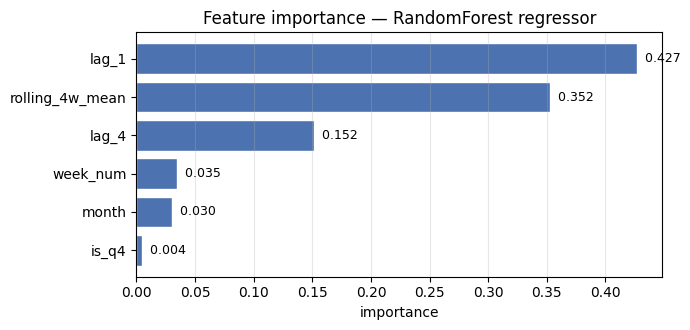

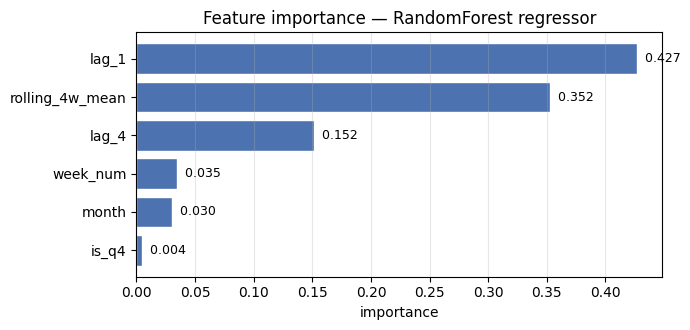

In [17]:
from olist.pipeline.demand import best_model_feature_importances

fi = best_model_feature_importances(spark)
fi.orderBy(F.col("importance").desc()).show()

# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — 6-row aggregate
fi_pd = fi.toPandas()
viz.feature_importance_bar(
    list(fi_pd[["feature", "importance"]].itertuples(index=False, name=None)),
    title=f"Feature importance — {metrics_pd.loc[0, 'best_name']} regressor",
)


### 5.3 Residual plot — actual vs predicted + histogram

A 1000-row sample of the full-model predictions is pulled to pandas for the two-panel diagnostic. A well-calibrated model clusters tightly around the y=x line and produces residuals centred on zero with no obvious heteroskedasticity. Large residual outliers are sellers whose weekly volume spikes unpredictably — the model's natural ceiling at this feature set.

sampled predictions: 1,000 rows


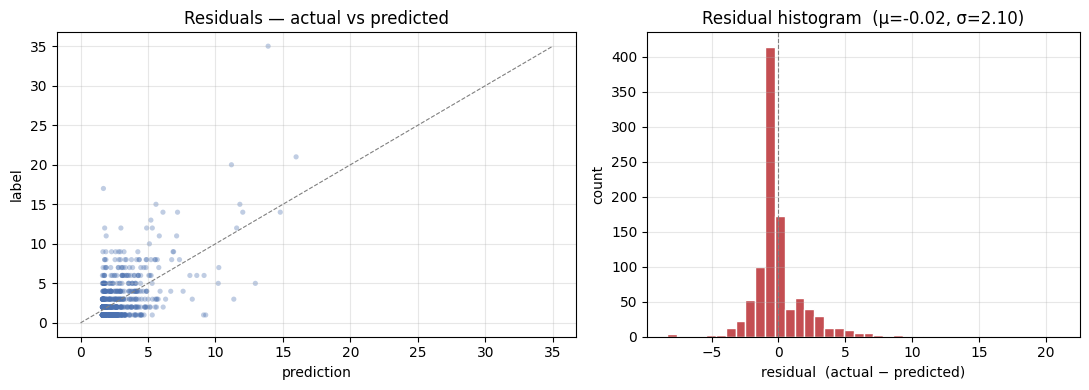

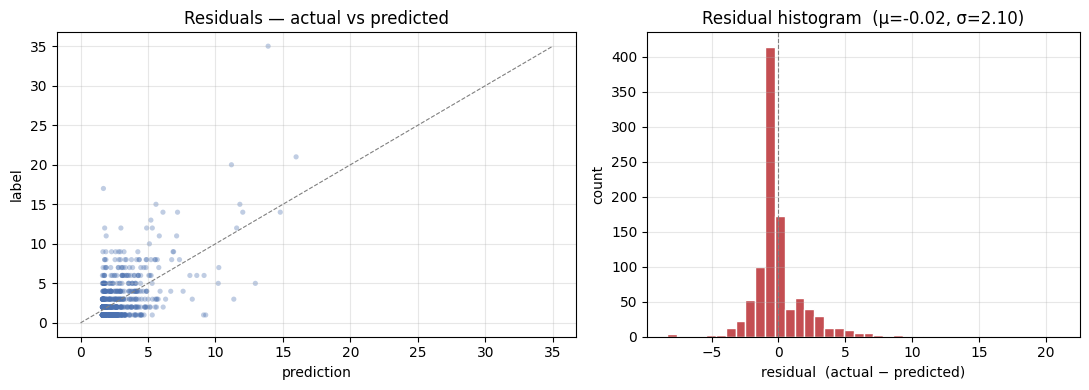

In [18]:
from olist.pipeline.demand import predictions_sample

# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 1000 rows
preds_pd = predictions_sample(spark, n=1000).toPandas()
print(f"sampled predictions: {len(preds_pd):,} rows")
viz.residual_plot(preds_pd, y_true="label", y_pred="prediction")


## 6. Deployment

The deployable artefacts are two committed parquets — one feeds NB2, one feeds the convergence layer.

### 6.1 Per-seller demand scores

In [19]:
demand_scores = scoring["nb1_seller_demand_scores"]
print(f"seller_demand_scores rows: {demand_scores.count():,}")
demand_scores.groupBy("delay_risk_flag").agg(F.count("*").alias("n")).orderBy("delay_risk_flag").show()


seller_demand_scores rows: 2,970
+---------------+----+
|delay_risk_flag|   n|
+---------------+----+
|              0|2904|
|              1|  66|
+---------------+----+



### 6.2 Top-10 sellers by forecast uplift — deployment-ready table

These are the sellers with the strongest predicted growth — the short-list for inventory-ramp-up conversations with the operations team. Bar-embedded on the uplift column, gradient on `avg_delay_days` (redder = later — growth + delay is the dangerous combination).

In [20]:
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 10 rows
top10_uplift = (
    demand_scores.orderBy(F.col("forecast_uplift_pct").desc()).limit(10).toPandas()
)
top10_uplift["seller_id"] = top10_uplift["seller_id"].str.slice(0, 10) + "…"
viz.styled_topn_table(
    top10_uplift,
    bar_cols=["forecast_uplift_pct"],
    gradient_cols=["avg_delay_days"],
    fmt={
        "forecast_uplift_pct": "{:+.1f}%",
        "avg_delay_days": "{:+.1f}",
        "delay_risk_flag": "{:d}",
    },
    title="Top-10 sellers by forecast uplift %",
)


seller_id,seller_state,forecast_uplift_pct,avg_delay_days,delay_risk_flag
6f892e20a1…,SP,+339.5%,-10.1,0
6973a06f48…,SP,+332.6%,-7.5,0
b8bc237ba3…,SC,+179.8%,-14.3,0
f08a5b9dd6…,RS,+161.3%,-8.4,0
6481e96574…,SP,+158.4%,-11.2,0
9c0e69c7bf…,SP,+155.4%,-8.1,0
8f119a0aee…,SP,+142.1%,-10.7,0
99a54764c3…,SP,+137.8%,-10.2,0
beadbee309…,SP,+137.8%,-9.7,0
9d4db00d65…,SP,+137.6%,-11.7,0


### 6.3 Clean up

In [21]:
ROOT_OUT = Path.cwd().parent / "outputs" if Path.cwd().name == "notebooks" else Path.cwd() / "outputs"
print("Notebook 1 outputs (committed):")
for path in sorted(ROOT_OUT.glob("*.parquet")):
    print(" ", path.name)
spark.stop()
print("\nSpark stopped.")


Notebook 1 outputs (committed):
  geo_centroids.parquet
  nb1_seller_demand_scores.parquet
  nb1_weekly_order_volume.parquet
  nb2_seller_sentiment_scores.parquet
  nb3_seller_network_scores.parquet
  seller_risk_index.parquet



Spark stopped.
